# Notebook 5 – Neural Network on Tabular Data with TensorFlow

In this notebook, we will:

- Take a cleaned **tabular dataset** of students.
- Optionally turn it into a **tf.data** pipeline (TensorFlow input pipeline).
- Build a small **Keras neural network** for binary classification (pass/fail).
- Train, evaluate, and compare the idea to our previous classical ML baseline.

This is a more "TensorFlow native" version of the pipeline you saw in Notebook 3.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Load or create dataset

In [2]:
# ---------- OPTION A: Load cleaned CSV from previous notebooks ----------
# Uncomment if you saved "students_clean.csv" earlier.
# df = pd.read_csv("students_clean.csv")

# ---------- OPTION B: Self-contained synthetic dataset ----------
np.random.seed(42)
tf.random.set_seed(42)

n = 300  # more rows to make NN training more sensible

data = {
    "student_id": np.arange(1, n + 1),
    "hours_studied": np.random.randint(0, 10, size=n).astype("float"),
    "previous_score": np.random.randint(30, 90, size=n).astype("float"),
    "attendance": np.random.randint(50, 100, size=n).astype("float"),
    "extra_classes": np.random.choice([0, 1], size=n).astype("float"),
    "final_score": np.random.randint(30, 95, size=n).astype("float"),
}

df = pd.DataFrame(data)

# Simple pass/fail label
df["passed"] = (df["final_score"] >= 50).astype(int)

df.head()


,student_id,hours_studied,previous_score,attendance,extra_classes,final_score,passed
0,1,6.0,66.0,68.0,1.0,58.0,1
1,2,3.0,53.0,61.0,1.0,62.0,1
2,3,7.0,58.0,58.0,1.0,56.0,1
3,4,4.0,78.0,56.0,1.0,65.0,1
4,5,6.0,75.0,77.0,0.0,58.0,1


## 1. Features and target for our TensorFlow model

We will again treat this as a **binary classification** problem:

- Input features:
  - `hours_studied`
  - `previous_score`
  - `attendance`
  - `extra_classes`
- Target label:
  - `passed` (1 = passed, 0 = failed)

Goal: learn a neural network that can predict **pass/fail** from these features.

Next, we prepare NumPy arrays for features and labels, then split into train/test sets.


In [3]:
feature_cols = ["hours_studied", "previous_score", "attendance", "extra_classes"]
target_col = "passed"

X = df[feature_cols].values.astype("float32")
y = df[target_col].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape


((240, 4), (60, 4))

In [4]:
# Create TensorFlow datasets from NumPy arrays
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train)).batch(batch_size)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size)

train_ds, test_ds


(<_BatchDataset element_spec=(TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>,
 <_BatchDataset element_spec=(TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>)

## 2. Why use `tf.data`?

The `tf.data` API lets you:

- Wrap your data into **datasets** that can be:
  - Shuffled
  - Batched
  - Prefetched
- Build efficient input pipelines that scale to larger datasets.

For this small demo, we **could** train directly on NumPy arrays.  
But showing `tf.data.Dataset.from_tensor_slices(...)` gives you a taste of how large tabular/image/text pipelines are built.


# Build the Keras model

In [5]:
def build_model(input_dim: int) -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    return model

model = build_model(input_dim=len(feature_cols))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the model

In [6]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)

# Train the model (Code)
If you want to avoid `tf.data`, replace `train_ds` with (X_train, y_train) and add `batch_size=` in `fit`.

In [10]:
epochs = 30

history = model.fit(
    train_ds,            # or (X_train, y_train) with batch_size=
    epochs=epochs,
    validation_data=test_ds,  # quick way: use test as validation for demo
    verbose=1,               # set to 1 to show progress
)

print("Training complete.")

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7042 - loss: 0.5998 - val_accuracy: 0.7000 - val_loss: 0.5983
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7042 - loss: 0.5965 - val_accuracy: 0.7000 - val_loss: 0.6020
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7042 - loss: 0.6086 - val_accuracy: 0.7000 - val_loss: 0.6027
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7042 - loss: 0.6206 - val_accuracy: 0.7000 - val_loss: 0.5997
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7042 - loss: 0.6128 - val_accuracy: 0.7000 - val_loss: 0.6066
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7000 - loss: 0.6285 - val_accuracy: 0.7000 - val_loss: 0.6057
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7042 - loss: 0.6105 - val_accuracy: 0.7000 - val_loss: 0.6014
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.6336 - val_accuracy: 0.7000 - val_loss: 0.5996
Epoch 9/

In [ ]:
# If you skip tf.data and train directly on NumPy arrays, use:

# python
# epochs = 30

# history = model.fit(
#     X_train,
#     y_train,
#     batch_size=32,
#     epochs=epochs,
#     validation_data=(X_test, y_test),
#     verbose=1,
# )

# print("\nTraining complete.")

# Evaluate on test data

In [11]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy (TensorFlow NN): {test_acc:.2f}")

Test accuracy (TensorFlow NN): 0.70


In [12]:
print('history keys:', history.history.keys())
for k, v in history.history.items():
    print(k, [round(float(x), 4) for x in v[:10]], '...')

history keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
accuracy [0.7042, 0.7042, 0.7042, 0.7042, 0.7042, 0.7, 0.7042, 0.6875, 0.7042, 0.7042] ...
loss [0.5998, 0.5965, 0.6086, 0.6206, 0.6128, 0.6285, 0.6105, 0.6336, 0.6093, 0.6157] ...
val_accuracy [0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7] ...
val_loss [0.5983, 0.602, 0.6027, 0.5997, 0.6066, 0.6057, 0.6014, 0.5996, 0.5997, 0.5954] ...


In [13]:
import numpy as np
print('Train positive rate:', float(np.mean(y_train)))
print('Test positive rate:', float(np.mean(y_test)))
majority_train = max(np.mean(y_train==0), np.mean(y_train==1))
majority_test = max(np.mean(y_test==0), np.mean(y_test==1))
print('Majority-class baseline train acc:', float(majority_train))
print('Majority-class baseline test acc :', float(majority_test))

pred_prob = model.predict(X_test, verbose=0).ravel()
pred = (pred_prob >= 0.5).astype(np.float32)
print('Predicted positive rate on test:', float(np.mean(pred)))
print('Mean predicted probability test:', float(np.mean(pred_prob)))

Train positive rate: 0.7041666507720947
Test positive rate: 0.699999988079071
Majority-class baseline train acc: 0.7041666666666667
Majority-class baseline test acc : 0.7
Predicted positive rate on test: 1.0
Mean predicted probability test: 0.7083704471588135


# Quick comparison to a classical baseline

In [14]:
from sklearn.linear_model import LogisticRegression

# Re-train a logistic regression on the same split for comparison
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_test_pred = log_reg.predict(X_test)
baseline_acc = accuracy_score(y_test, y_test_pred)

print(f"Baseline logistic regression accuracy: {baseline_acc:.2f}")
print(f"TensorFlow NN accuracy:               {test_acc:.2f}")


Baseline logistic regression accuracy: 0.70
TensorFlow NN accuracy:               0.70


# Inspect predictions

In [15]:
# Get a few predictions from the neural network
sample_X = X_test[:5]
sample_y = y_test[:5]

nn_probs = model.predict(sample_X)
nn_preds = (nn_probs >= 0.5).astype(int).reshape(-1)

for i, (features, true_label, prob, pred) in enumerate(
    zip(sample_X, sample_y, nn_probs, nn_preds)
):
    print(
        f"Sample {i+1}: hours={features[0]}, prev_score={features[1]}, "
        f"attendance={features[2]}, extra_classes={int(features[3])} "
        f"=> nn_prob={prob[0]:.2f}, nn_pred={pred}, true_label={int(true_label)}"
    )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Sample 1: hours=5.0, prev_score=31.0, attendance=62.0, extra_classes=1 => nn_prob=0.63, nn_pred=1, true_label=0
Sample 2: hours=2.0, prev_score=54.0, attendance=87.0, extra_classes=0 => nn_prob=0.72, nn_pred=1, true_label=1
Sample 3: hours=8.0, prev_score=51.0, attendance=90.0, extra_classes=1 => nn_prob=0.72, nn_pred=1, true_label=0
Sample 4: hours=8.0, prev_score=30.0, attendance=54.0, extra_classes=1 => nn_prob=0.63, nn_pred=1, true_label=0
Sample 5: hours=7.0, prev_score=50.0, attendance=84.0, extra_classes=0 => nn_prob=0.73, nn_pred=1, true_label=0


# Training curves

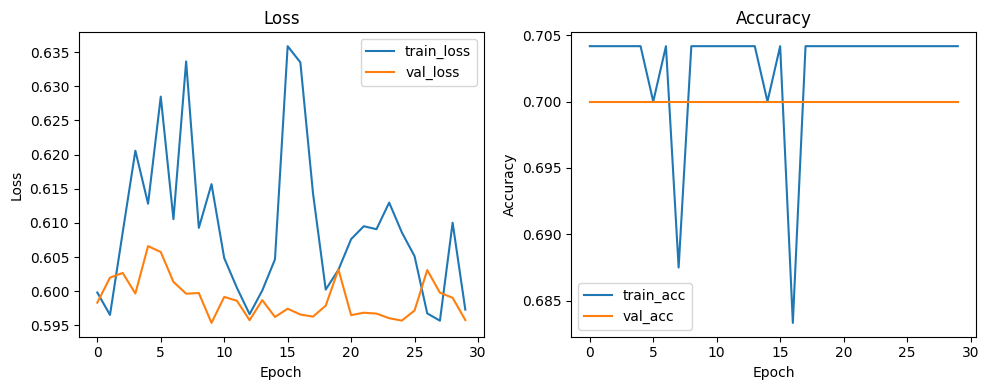

In [16]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["loss"], label="train_loss")
plt.plot(history_dict["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["accuracy"], label="train_acc")
plt.plot(history_dict["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


## 3. What you saw in this notebook

In this notebook, we:

- Took a cleaned **tabular dataset** and split it into train/test sets.
- (Optionally) wrapped the NumPy arrays into a **tf.data** pipeline with shuffling and batching.
- Built a small **Keras Sequential** model with `Dense` layers for binary classification.
- Trained the model with `model.fit(...)` and evaluated it with `model.evaluate(...)`.
- Compared its accuracy to a **logistic regression baseline**.

The key takeaways:

- The **data pipeline** (X/y, train/test) is almost the same for classical ML and deep learning.
- TensorFlow/Keras mainly changes **how we define and train the model**.
- For tabular data, simple models can already perform well; neural networks become more useful as:
  - Data grows larger,
  - Relationships become more complex, and
  - You mix tabular features with other modalities (images, text, etc.).

In the final notebook, we’ll focus on:
- Showcasing **real-world demos** (images/text) built with TensorFlow.
- Giving you a **roadmap** for what to learn next after this bootcamp.
